# K-Nearest Neighbors from Scratch
## CMOR 438 / INDE 577 — Qiushi Han

K-Nearest Neighbors (KNN) is a **non-parametric, instance-based** classification algorithm. It makes predictions by:

1. Computing the distance from a test point to every training point
2. Selecting the **k nearest** neighbors
3. Returning the **majority class** among those neighbors

We use **Euclidean distance**:

$$d(x_1, x_2) = \sqrt{\sum_{i=1}^{n}(x_{1,i} - x_{2,i})^2}$$

KNN has no training phase as all computation happens at prediction time.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split as sklearn_split

from rice_ml.supervised_learning.knn import KNN
from rice_ml.processing.metrics import accuracy_score, confusion_matrix
from rice_ml.processing.preprocessing import StandardScaler

## Loading and Exploring the Dataset

We use the classic **Iris dataset**: 150 flowers, 4 features (sepal/petal length and width), and 3 classes (setosa, versicolor, virginica).

In [2]:
data = load_iris()
X, y = data.data, data.target

print(f"Dataset shape: {X.shape}")
print(f"Classes: {data.target_names}")
print(f"Class distribution: {np.bincount(y)}")

Dataset shape: (150, 4)
Classes: ['setosa' 'versicolor' 'virginica']
Class distribution: [50 50 50]


## Preprocessing and Train/Test Split

In [4]:
X_train, X_test, y_train, y_test = sklearn_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

scaler = StandardScaler().fit(X_train)
X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Training samples: {X_train.shape[0]}")
print(f"Test samples: {X_test.shape[0]}")

Training samples: 120
Test samples: 30


## Training and Evaluation Across Different k Values

Choosing the right **k** is critical:
- Small k → low bias, high variance (overfitting)
- Large k → high bias, low variance (underfitting)

Crucial to compare accuracy across multiple values of k.

k_values = [1, 3, 5, 7, 9, 11, 15, 21]
accuracies = []

for k in k_values:
    model = KNN(k=k).fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)
    acc = accuracy_score(y_test, y_pred)
    accuracies.append(acc)
    print(f"k = {k:2d} | Accuracy = {acc:.4f}")

## Visualizing Accuracy vs k

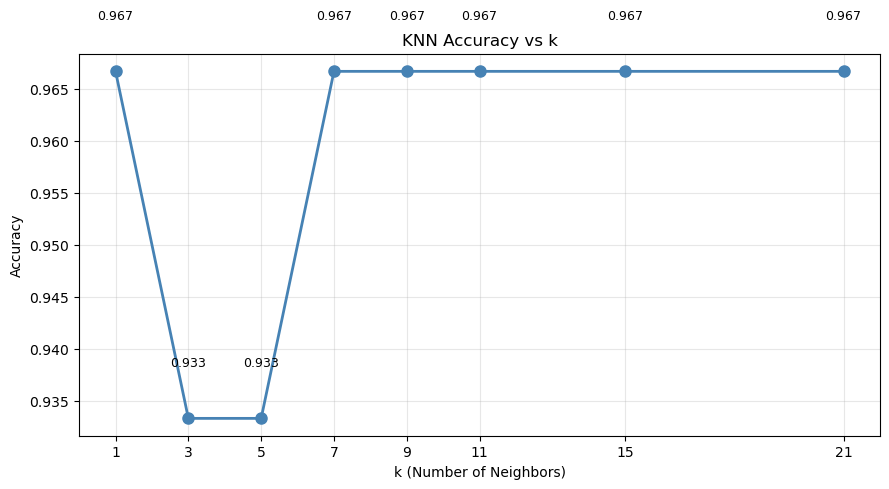

In [9]:
plt.figure(figsize=(9, 5))
plt.plot(k_values, accuracies, marker='o', linewidth=2,
         markersize=8, color='steelblue')
plt.xlabel('k (Number of Neighbors)')
plt.ylabel('Accuracy')
plt.title('KNN Accuracy vs k')
plt.grid(True, alpha=0.3)
plt.xticks(k_values)
for k, acc in zip(k_values, accuracies):
    plt.text(k, acc + 0.005, f'{acc:.3f}', ha='center', fontsize=9)
plt.tight_layout()
plt.show()

## Decision Boundary Visualization (using 2 features)

To visualize how KNN separates classes, we will train it on just the first two features (sepal length and sepal width) and plot the decision boundary.

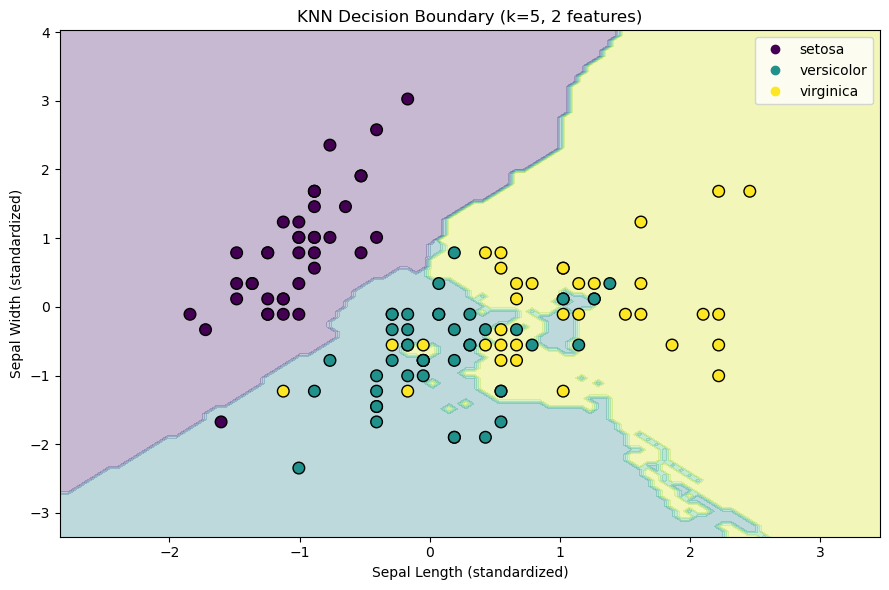

In [11]:
# Use only the first 2 features for visualization
X_2d = X[:, :2]
X_train_2d, X_test_2d, y_train_2d, y_test_2d = sklearn_split(
    X_2d, y, test_size=0.2, random_state=42, stratify=y)

scaler_2d = StandardScaler().fit(X_train_2d)
X_train_2d_scaled = scaler_2d.transform(X_train_2d)

model_2d = KNN(k=5).fit(X_train_2d_scaled, y_train_2d)

# Create mesh grid
x_min, x_max = X_train_2d_scaled[:, 0].min() - 1, X_train_2d_scaled[:, 0].max() + 1
y_min, y_max = X_train_2d_scaled[:, 1].min() - 1, X_train_2d_scaled[:, 1].max() + 1
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 100),
                     np.linspace(y_min, y_max, 100))
Z = model_2d.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

plt.figure(figsize=(9, 6))
plt.contourf(xx, yy, Z, alpha=0.3, cmap='viridis')
scatter = plt.scatter(X_train_2d_scaled[:, 0], X_train_2d_scaled[:, 1],
                      c=y_train_2d, cmap='viridis', edgecolors='k', s=70)
plt.xlabel('Sepal Length (standardized)')
plt.ylabel('Sepal Width (standardized)')
plt.title('KNN Decision Boundary (k=5, 2 features)')
plt.legend(handles=scatter.legend_elements()[0], labels=list(data.target_names))
plt.tight_layout()
plt.show()

## Discussion

- KNN achieves **96.7% accuracy** for most values of k, demonstrating strong performance on the Iris dataset
- Interestingly, k=3 and k=5 both drop to **93.3%**. At these k values, the model picks up local noise from the overlapping versicolor/virginica region
- Accuracy stabilizes at 96.7% for k≥7, suggesting that averaging over more neighbors smooths out the noise in the boundary region
- The decision boundary plot reveals why: **setosa** (purple) is linearly separable from the other two, but **versicolor** (teal) and **virginica** (yellow) overlap significantly in sepal-feature space
- KNN handles this multi-class problem well without any explicit modeling of class boundaries. It simply lets the data speak for itself
- Feature scaling was essential since the four features have different ranges (sepal length ~4-8 cm vs sepal width ~2-4 cm)
- The downside is that KNN computes distances to every training point at prediction time, making it slow on large datasets